In [2]:
!git clone https://github.com/beckhamtoh/CS3244-Gun-Violence.git
%cd CS3244-Gun-Violence

from google.colab import files
import pandas as pd

uploaded = files.upload()


Cloning into 'CS3244-Gun-Violence'...
remote: Enumerating objects: 24539, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 24539 (delta 10), reused 18 (delta 4), pack-reused 24508 (from 1)
Receiving objects: 100% (24539/24539), 188.85 MiB | 23.74 MiB/s, done.
Resolving deltas: 100% (2744/2744), done.
/content/CS3244-Gun-Violence


Saving guns_encoded.csv to guns_encoded.csv


# Inspecting the dataset

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score, precision_score,  balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier




for filename in uploaded.keys():
    print(f"Loaded: {filename}")
    df = pd.read_csv(filename)

print(df.head())

Loaded: guns_encoded.csv
   S.No.  Year  Month        Date   Age  Hispanic  Police involvement  \
0      1  2017      1  2017-01-06  35.0       100                   0   
1      2  2017      1  2017-01-19  22.0       100                   0   
2      3  2017      1  2017-01-01  61.0       100                   0   
3      4  2017      2  2017-02-06  65.0       100                   0   
4      5  2017      2  2017-02-09  32.0       100                   0   

   isWeekend  Reason_Accidental  Reason_Homicide  ...  \
0          0                0.0              0.0  ...   
1          0                0.0              0.0  ...   
2          1                0.0              0.0  ...   
3          0                0.0              0.0  ...   
4          0                0.0              0.0  ...   

   Place of incident_Street  Place of incident_Trade/service area  \
0                       0.0                                   0.0   
1                       1.0                            

# Splitting the data into x and y

In [4]:



# Find all one-hot columns for Reason
reason_cols = [col for col in df.columns if col.startswith("Reason_")]

# Convert them back to a single column (take the column name with 1)
df["Reason"] = df[reason_cols].idxmax(axis=1).str.replace("Reason_", "")

# Drop those dummy columns
df = df.drop(columns=reason_cols)

# Now split
y = df["Reason"]
x = df.drop(["Reason", "S.No.", "Date", "Year", "Month"], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)

print(y.head())
print(x.head())

0    Suicide
1    Suicide
2    Suicide
3    Suicide
4    Suicide
Name: Reason, dtype: object
    Age  Hispanic  Police involvement  isWeekend  Education_Bachelors  \
0  35.0       100                   0          0                  1.0   
1  22.0       100                   0          0                  0.0   
2  61.0       100                   0          1                  1.0   
3  65.0       100                   0          0                  1.0   
4  32.0       100                   0          0                  0.0   

   Education_High School  Education_Less than High School  \
0                    0.0                              0.0   
1                    0.0                              0.0   
2                    0.0                              0.0   
3                    0.0                              0.0   
4                    1.0                              0.0   

   Education_Some college  Education_Unknown  Sex_Female  ...  \
0                     0.0           

#Logistic Regression



### Baseline Logistic Regression model

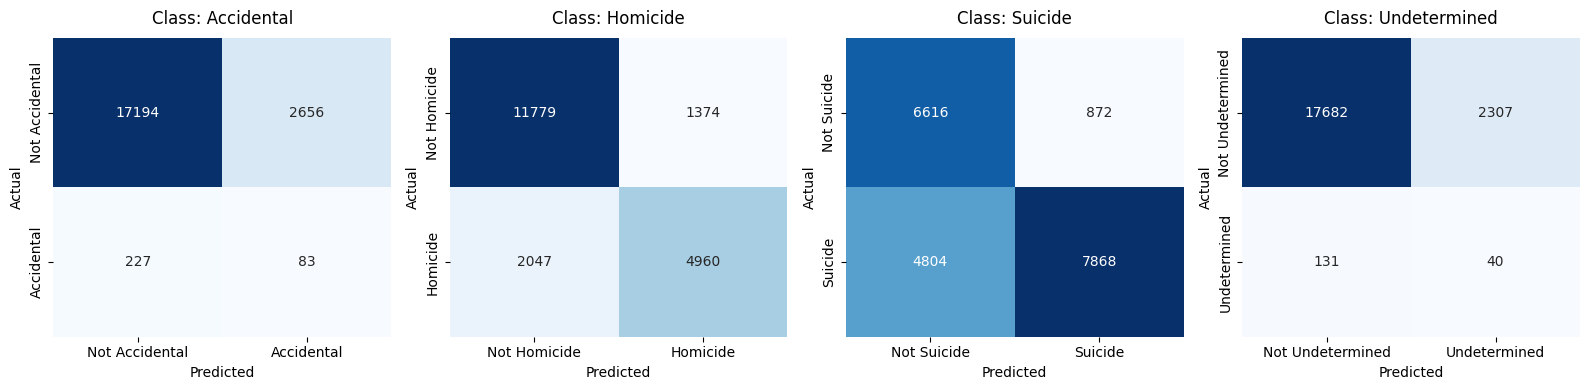

=== Logistic Regression Results ===
Accuracy: 0.6424
F1 (Macro): 0.3912

Classification Report:
              precision    recall  f1-score   support

  Accidental       0.03      0.27      0.05       310
    Homicide       0.78      0.71      0.74      7007
     Suicide       0.90      0.62      0.73     12672
Undetermined       0.02      0.23      0.03       171

    accuracy                           0.64     20160
   macro avg       0.43      0.46      0.39     20160
weighted avg       0.84      0.64      0.72     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.6424
Precision: 0.6424
Recall: 0.6424


In [5]:
# Preprocessing

# Only continuous numeric columns go here
num_cols = ["Age", "Hispanic"]

num_transformer = Pipeline([
    ("scaler", StandardScaler())
])

# Everything else (binary, one-hot, etc.) passes through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
    ],
    remainder="passthrough"
)

# comments: use one hot encoder instead of label encoder because for features with more than 2 categories label encoder will create some sort of ranking/ level difference when in fact there is not

baseline_log_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight = "balanced", penalty = "l2"))
])

baseline_log_reg.fit(x_train, y_train)

# -------------------- Predict --------------------
y_pred = baseline_log_reg.predict(x_test)



# --- Get confusion matrix for each class ---
class_labels = baseline_log_reg.classes_
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=class_labels)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(class_labels), figsize=(4 * len(class_labels), 4))

# Make sure axes is iterable even if there’s only one class
if len(class_labels) == 1:
    axes = [axes]

for ax, label, cm in zip(axes, class_labels, mcm):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

    # Set readable class labels instead of numeric ticks
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels([f'Not {label}', label])
    ax.set_yticklabels([f'Not {label}', label])

    ax.set_title(f'Class: {label}', fontsize=12, pad=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)


plt.tight_layout()
plt.show()

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("=== Logistic Regression Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")




# Comments:
# log_reg cannot capture non_linear relationship?
# class_weight = "balanced" gives higher importance to minority classes and lower weight to majority ones based on their frequency, helps to improve precision and recall scores for the minority classes
# If I use class_weight = None, I will get 0 for recall and precision for accidental and undetermined
# max_iter = 1000 becos we have 100,000+ entries and many features after one-hot encoding

# To improve:
# Can try different regularisations by tuning (eg penalty = "l1" and different C values in log_reg). Default is l2 regularization.
# Small C means strong penalty on large weights, coeff shrink leading to simpler model. Large c means negligible regularisation, model fits data more flexibly, risk of overfitting



### Using L1 regularisation instead of L2.


In [6]:


log_reg_L1 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight = "balanced", penalty = "l1", solver = "saga", n_jobs= -1 ))
])

log_reg_L1.fit(x_train, y_train)

# -------------------- Predict --------------------
y_pred = log_reg_L1.predict(x_test)



acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("=== Logistic Regression Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== Logistic Regression Results ===
Accuracy: 0.6100
F1 (Macro): 0.3750

Classification Report:
              precision    recall  f1-score   support

  Accidental       0.02      0.31      0.05       310
    Homicide       0.81      0.61      0.69      7007
     Suicide       0.90      0.62      0.74     12672
Undetermined       0.01      0.16      0.02       171

    accuracy                           0.61     20160
   macro avg       0.44      0.43      0.38     20160
weighted avg       0.85      0.61      0.71     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.6100
Precision: 0.6100
Recall: 0.6100


###Tuning the C value

In [7]:
# ----- Hyperparameter grid: tuning C -----
param_grid = {
    "classifier__C": np.logspace(-3, 2, 12)   # creates an array of 12 numbers evenly spaced on a logarithmic scale between 10^-3 to 10^2
}

# ----- Cross Validation & scoring -----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "f1_macro": "f1_macro",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy" # avg recall per class
}

grid = GridSearchCV(
    estimator=baseline_log_reg,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",    # pick model with best macro-F1
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# ----- Fit search -----
grid.fit(x_train, y_train)
print("\n=== New ===")
print("Best params:", grid.best_params_)
print(f"Best CV f1_macro: {grid.best_score_:.4f}")

best_L2_tuned = grid.best_estimator_

# ----- Predict & report (reusing your style) -----
y_pred = best_L2_tuned.predict(x_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
f1_micro = f1_score(y_test, y_pred, average="micro", zero_division=0)
precision_micro = precision_score(y_test, y_pred, average="micro", zero_division=0)
recall_micro = recall_score(y_test, y_pred, average="micro", zero_division=0)

print("\n=== Tuned L2 Logistic Regression Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comments
# We used macro-F1 as a metric to find the best c value
# Why macro-F1 is fairer for imbalanced data:
# Gives equal importance to all classes — even the small ones.
# Rewards models that improve recall/precision for the minority categories (like Accidental and Undetermined).
# Penalizes models that only perform well on the dominant class (Suicide).
# tells you whether the model performs reasonably across all classes, not just the popular ones.


Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== New ===
Best params: {'classifier__C': np.float64(0.001)}
Best CV f1_macro: 0.3949

=== Tuned L2 Logistic Regression Results ===
Accuracy: 0.6524
F1 (Macro): 0.3943

Classification Report:
              precision    recall  f1-score   support

  Accidental       0.03      0.23      0.05       310
    Homicide       0.78      0.74      0.76      7007
     Suicide       0.90      0.62      0.73     12672
Undetermined       0.02      0.22      0.03       171

    accuracy                           0.65     20160
   macro avg       0.43      0.45      0.39     20160
weighted avg       0.84      0.65      0.73     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.6524
Precision: 0.6524
Recall: 0.6524


## Comparison of the logistic regression models

In [8]:
# Helper function
def evaluate_model(model, x_train, y_train, x_test, y_test, model_name):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_test, y_pred, average="micro", zero_division=0)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1 (Macro)": f1_macro,
        "F1 (Micro)": f1_micro,
        "Precision (Macro)": precision_macro,
        "Recall (Macro)": recall_macro
    }

    # ------------------------------------------------------------
# Evaluate all three models
# ------------------------------------------------------------
results = []
results.append(evaluate_model(baseline_log_reg, x_train, y_train, x_test, y_test, "Baseline L2 (C=1.0)"))
results.append(evaluate_model(log_reg_L1, x_train, y_train, x_test, y_test, "L1 Regularization"))
results.append(evaluate_model(best_L2_tuned, x_train, y_train, x_test, y_test, f"Tuned L2 (C={grid.best_params_['classifier__C']})"))

# ------------------------------------------------------------
# Create and display results table
# ------------------------------------------------------------
df_results = pd.DataFrame(results)
df_results.set_index("Model", inplace=True)
print("\n=== Comparison of Logistic Regression Models ===")
display(df_results.round(4))

# Comments:
# the tuned L2 model has better performance in most metrics other than Recall (Macro)
# However, the improvement is quite insignificant ~ 0.01

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Comparison of Logistic Regression Models ===


,Accuracy,F1 (Macro),F1 (Micro),Precision (Macro),Recall (Macro)
Model,,,,,
Baseline L2 (C=1.0),0.6424,0.3912,0.6424,0.4327,0.4576
L1 Regularization,0.6100,0.3750,0.6100,0.4357,0.4260
Tuned L2 (C=0.001),0.6524,0.3943,0.6524,0.4321,0.4530


## Further evaluating the tuned L2 model



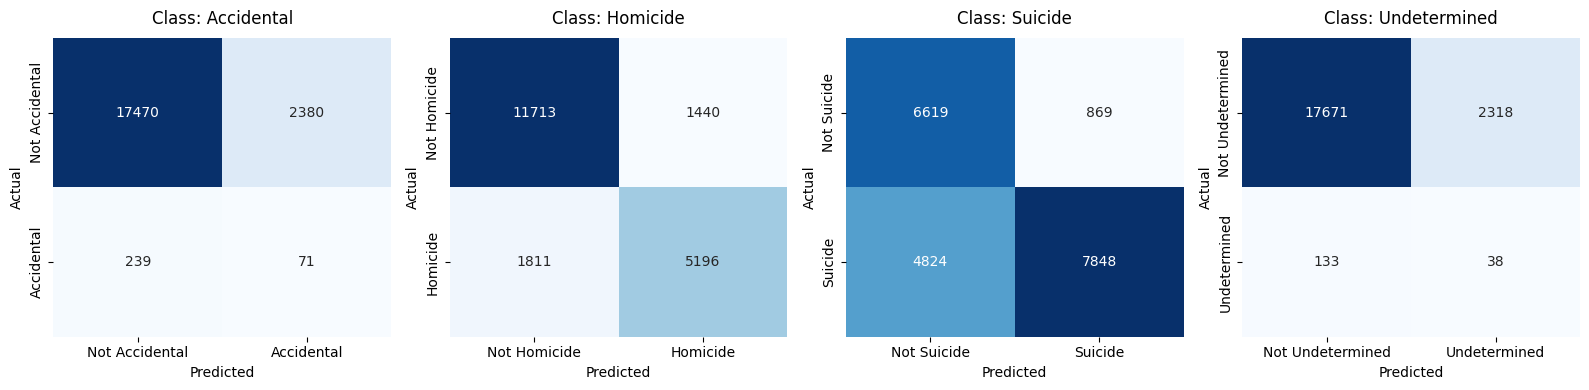

=== Results ===
Accuracy: 0.6524
F1 (Macro): 0.3943

Classification Report:
              precision    recall  f1-score   support

  Accidental       0.03      0.23      0.05       310
    Homicide       0.78      0.74      0.76      7007
     Suicide       0.90      0.62      0.73     12672
Undetermined       0.02      0.22      0.03       171

    accuracy                           0.65     20160
   macro avg       0.43      0.45      0.39     20160
weighted avg       0.84      0.65      0.73     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.6524
Precision: 0.6524
Recall: 0.6524


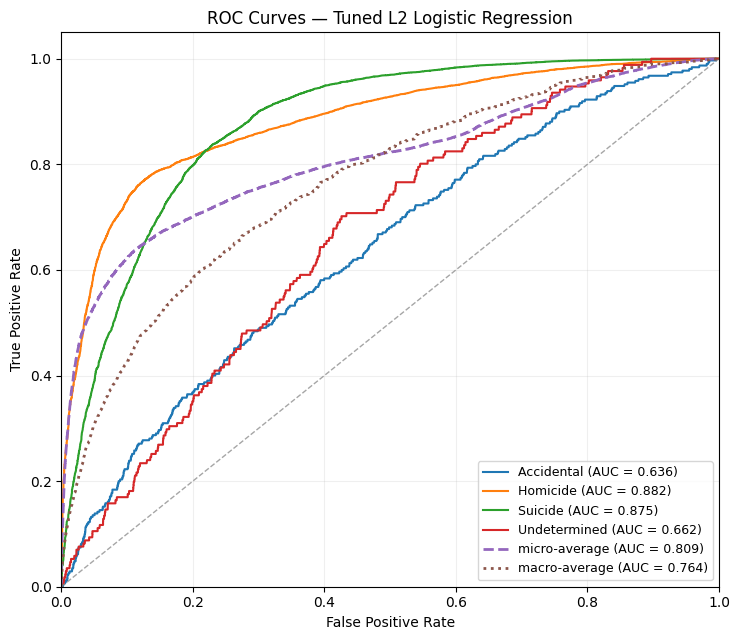

In [15]:
y_pred = best_L2_tuned.predict(x_test)

#--- Get confusion matrix for each class ---
class_labels = best_L2_tuned.classes_
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=class_labels)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(class_labels), figsize=(4 * len(class_labels), 4))

# Make sure axes is iterable even if there’s only one class
if len(class_labels) == 1:
    axes = [axes]

for ax, label, cm in zip(axes, class_labels, mcm):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

    # Set readable class labels instead of numeric ticks
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels([f'Not {label}', label])
    ax.set_yticklabels([f'Not {label}', label])

    ax.set_title(f'Class: {label}', fontsize=12, pad=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)


plt.tight_layout()
plt.show()

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("=== Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")


# ---- Probabilities + binarized truth ----
class_labels = best_L2_tuned.classes_          # already used earlier in your code
y_score = best_L2_tuned.predict_proba(x_test)  # (n_samples, n_classes)
y_test_bin = label_binarize(y_test, classes=class_labels)

n_classes = len(class_labels)
fpr, tpr, roc_auc = {}, {}, {}

# ---- One-vs-rest ROC per class ----
for i in range(n_classes):
    # Skip if the class is completely absent/present in y_test (roc_curve would error)
    pos_count = y_test_bin[:, i].sum()
    if pos_count == 0 or pos_count == y_test_bin.shape[0]:
        print(f"[WARN] Skipping class '{class_labels[i]}' in ROC (no positive/negative samples in y_test).")
        continue
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ---- Micro-average ROC ----
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# ---- Macro-average ROC ----
# Aggregate all FPRs then interpolate the mean TPR
all_fpr = np.unique(np.concatenate([fpr[i] for i in fpr if isinstance(i, int)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    if i in fpr:  # only classes we computed
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= max(1, len([i for i in range(n_classes) if i in fpr]))

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ---- Plot ----
plt.figure(figsize=(7.5, 6.5))

# Per-class curves
for i in range(n_classes):
    if i in fpr:
        plt.plot(fpr[i], tpr[i], lw=1.5, label=f"{class_labels[i]} (AUC = {roc_auc[i]:.3f})")

# Micro & macro
plt.plot(fpr["micro"], tpr["micro"], lw=2, linestyle="--",
         label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], lw=2, linestyle=":",
         label=f"macro-average (AUC = {roc_auc['macro']:.3f})")

# Chance line
plt.plot([0, 1], [0, 1], linestyle="--", lw=1, color="gray", alpha=0.7)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Tuned L2 Logistic Regression")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Feature importance




                                      Feature  MeanAbsCoefficient
14                            cat__Race_White            0.389780
11                            cat__Race_Black            0.339717
23              cat__Place of incident_Street            0.309050
19   cat__Place of incident_Other unspecified            0.302731
16                cat__Place of incident_Home            0.246194
2                     num__Police involvement            0.179367
0                                    num__Age            0.179036
5        cat__Education_Less than High School            0.122383
3                    cat__Education_Bachelors            0.121537
8                             cat__Sex_Female            0.120003
9                               cat__Sex_Male            0.119547
12                         cat__Race_Hispanic            0.081979
24  cat__Place of incident_Trade/service area            0.080176
4                  cat__Education_High School            0.072028
18     cat

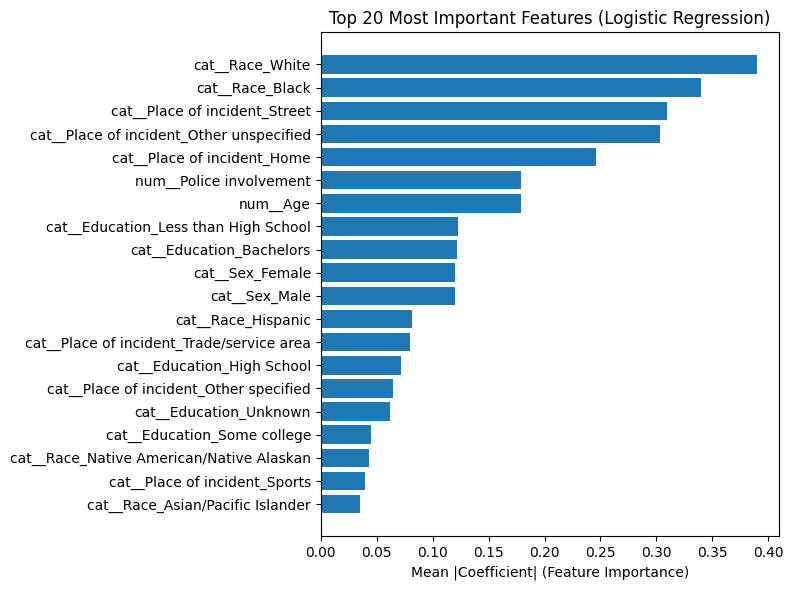

      OriginalFeature  MeanAbsCoefficient
3   Place of incident            1.127808
5                Race            0.889515
1           Education            0.423139
6                 Sex            0.239551
4  Police involvement            0.179367
0                 Age            0.179036
2            Hispanic            0.024750


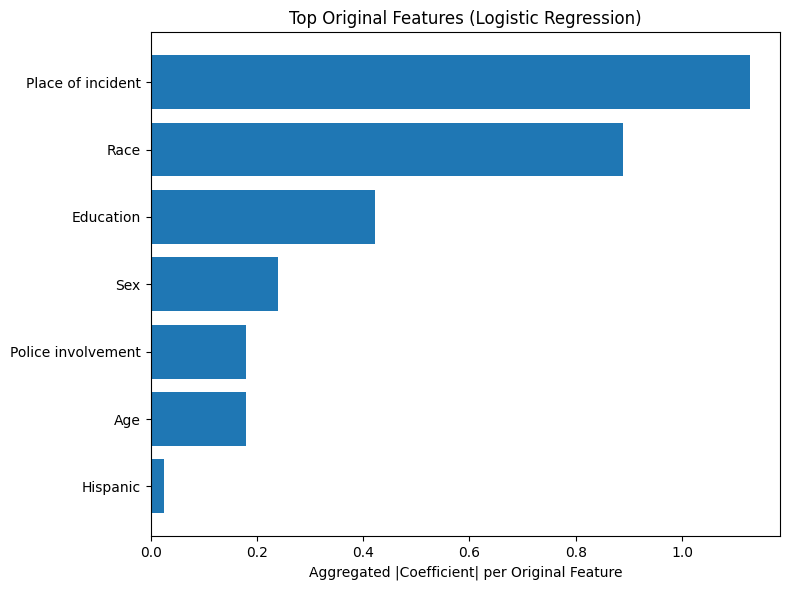

In [ ]:
pipe = best_L2_tuned  # or log_reg

# Extract the classifier and feature names
log_reg = pipe.named_steps["classifier"]
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()

# Coefficients per class (multiclass)
coef = log_reg.coef_   # shape = (n_classes, n_features)
classes = log_reg.classes_

# ---- Compute average absolute coefficient across classes ----
mean_abs_coef = np.mean(np.abs(coef), axis=0)

# Create a DataFrame
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsCoefficient": mean_abs_coef
}).sort_values("MeanAbsCoefficient", ascending=False)

# Display top 20
print(feat_imp.head(20))

# ---- Plot top 20 ----
plt.figure(figsize=(8,6))
plt.barh(feat_imp["Feature"].head(20)[::-1],
         feat_imp["MeanAbsCoefficient"].head(20)[::-1])
plt.xlabel("Mean |Coefficient| (Feature Importance)")
plt.title("Top 20 Most Important Features (Logistic Regression)")
plt.tight_layout()
plt.show()

def base_name(col):
    # Strip column-transformer prefix
    if "__" in col:
        prefix, rest = col.split("__", 1)
    else:
        rest = col
    # Take only the base feature before underscore
    if "_" in rest:
        return rest.split("_", 1)[0]
    return rest

# Map OHE features back to original
orig_names = [base_name(c) for c in feature_names]

agg_imp = (
    pd.DataFrame({"OriginalFeature": orig_names,
                  "MeanAbsCoefficient": mean_abs_coef})
    .groupby("OriginalFeature", as_index=False)
    .sum()
    .sort_values("MeanAbsCoefficient", ascending=False)
)

print(agg_imp.head(15))

# Plot aggregated importances
plt.figure(figsize=(8,6))
plt.barh(agg_imp["OriginalFeature"].head(15)[::-1],
         agg_imp["MeanAbsCoefficient"].head(15)[::-1])
plt.xlabel("Aggregated |Coefficient| per Original Feature")
plt.title("Top Original Features (Logistic Regression)")
plt.tight_layout()
plt.show()


#KNN model

## Baseline KNN model



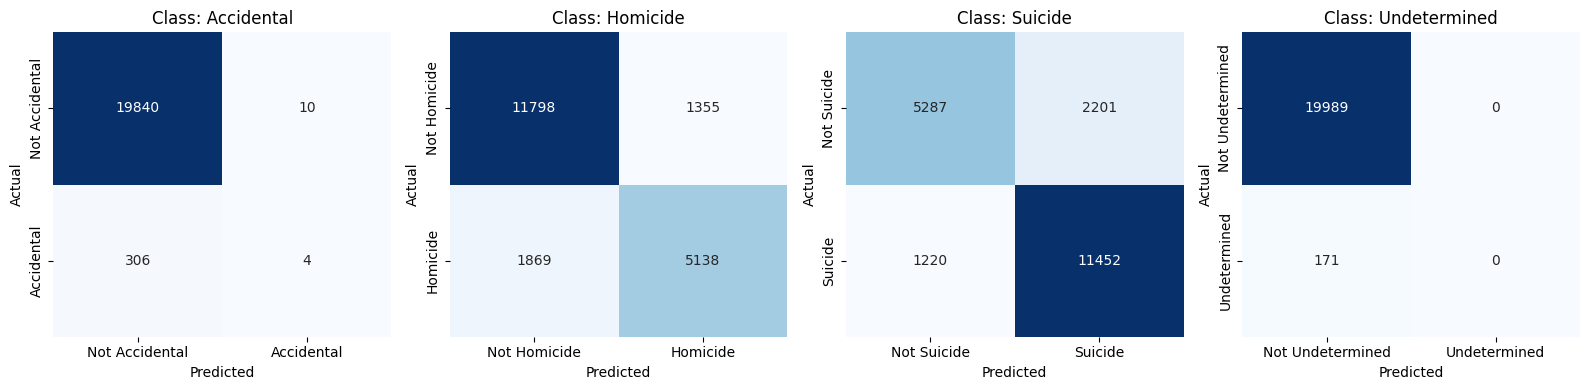

=== KNN (Manhattan) Results ===
Accuracy: 0.8231
F1 (Macro): 0.4140
Precision (Macro): 0.4790
Recall (Macro): 0.4125

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.01      0.02       310
           1       0.79      0.73      0.76      7007
           2       0.84      0.90      0.87     12672
           3       0.00      0.00      0.00       171

    accuracy                           0.82     20160
   macro avg       0.48      0.41      0.41     20160
weighted avg       0.81      0.82      0.81     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.8231
Precision: 0.8231
Recall: 0.8231


In [9]:
### PRE-PROCESSING ###


# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size = 0.2, random_state = 20)


knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=7,
        metric='manhattan',
        weights='uniform'
    ))
])

# --- Train the model ---
knn.fit(x_train, y_train)

# --- Predictions ---
y_pred = knn.predict(x_test)



# --- Get confusion matrix for each class ---
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=knn.classes_)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(knn.classes_), figsize=(16, 4))

# Get the original class labels from the label encoder
original_labels = label_encoder.classes_

for i, (ax, label_index) in enumerate(zip(axes, knn.classes_)):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {original_labels[label_index]}') # Use original label for title
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.xaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks
    ax.yaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks


plt.tight_layout()
plt.show()

# --- Evaluation ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("=== KNN (Manhattan) Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comments:
# I used random k = 7
# We have to use label encoder for KNN unlike in log_reg because KNN needs numeric y while models like log_reg, DT/Random Forest internally map class labels to numeric indices automatically using a built-in encoder.
# Use manhatten distance instead of euclidean distance because the dataset has categorical features and after one hot encoding, these features become binary (0/1).
# Manhattan measures how many binary positions differ — perfect for 0/1 data.
# Euclidean distance squares differences, which exaggerates large numeric gaps.
# Manhattan treats all dimensions more evenly → more robust with mixed scales.
# weights = "uniform" --> It’s simpler and more stable for noisy, real-world data. "uniform" avoids overfitting to the exact numeric scaling of features.
# weights = "distance" means closer neighbours gets more influence, distance weighted voting
# This takes quite long to run

# To improve:
# tune n_neighbours using k fold CV, maybe can try weights = "distance"?


## Tuning k

In [10]:


# ----- Pipeline: KNN (Manhattan) -----
knn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        metric="manhattan",
        weights="uniform",   # we'll also try "distance" in the grid below
        n_jobs=-1            # parallelize neighbor searches
    )),
])

# ----- Hyperparameter grid -----
# Odd ks reduce ties. Adjust upper bound based on runtime.
param_grid = {
    "classifier__n_neighbors": list(range(1, 41, 2))  # 1,3,5,...,39
    #"classifier__weights": ["uniform", "distance"],    # try both
    # keep metric fixed to 'manhattan' as you justified for one-hot data
}

# ----- CV & scoring (macro-F1 for selection, track others) -----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "f1_macro": "f1_macro",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy" # avg recall per class
}

grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",     # choose model by macro-F1
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# ----- Run search -----
grid.fit(x_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")

best_knn = grid.best_estimator_

# ----- Test-set evaluation -----
y_pred = best_knn.predict(x_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Acc": balanced_accuracy_score(y_test, y_pred),
    "F1 (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "F1 (Micro)": f1_score(y_test, y_pred, average="micro", zero_division=0),
    "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
}
print("\n=== Tuned KNN (Manhattan) Test Metrics ===")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# I think this will take very long to run, I gave up at 30 mins
# After this i still need to plot the ROC-AUC curve

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'classifier__n_neighbors': 5}
Best CV macro-F1: 0.4132

=== Tuned KNN (Manhattan) Test Metrics ===
Accuracy: 0.8140
Balanced Acc: 0.4115
F1 (Macro): 0.4145
F1 (Micro): 0.8140
Precision (Macro): 0.4458
Recall (Macro): 0.4115

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.03      0.04       310
           1       0.77      0.73      0.75      7007
           2       0.84      0.89      0.86     12672
           3       0.00      0.00      0.00       171

    accuracy                           0.81     20160
   macro avg       0.45      0.41      0.41     20160
weighted avg       0.80      0.81      0.80     20160



## Comparing the KNN models

In [11]:
# --- Baseline KNN (k = 7) ---
knn_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=7,
        metric="manhattan",
        weights="uniform",
        n_jobs=-1
    ))
])

# --- Tuned KNN (k = 5) ---
knn_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        metric="manhattan",
        weights="uniform",
        n_jobs=-1
    ))
])

# --- Evaluate both models ---
results = []
results.append(evaluate_model(knn_baseline, x_train, y_train, x_test, y_test, "Baseline KNN (k=7)"))
results.append(evaluate_model(knn_tuned, x_train, y_train, x_test, y_test, "Tuned KNN (k=5)"))

# --- Create and display DataFrame ---
df_knn_results = pd.DataFrame(results)
df_knn_results.set_index("Model", inplace=True)
print("=== Comparison of KNN Models ===")
display(df_knn_results.round(4))

# Comments:
# The tuned KNN model (k=5) shows similar performance to the baseline (k=7),
# with only marginal differences (< 0.01) in F1 (Macro) and Accuracy.
# This suggests that KNN performance is relatively stable around these k values.
# Minor variation may be due to cross-validation randomness or data imbalance.

=== Comparison of KNN Models ===


,Accuracy,F1 (Macro),F1 (Micro),Precision (Macro),Recall (Macro)
Model,,,,,
Baseline KNN (k=7),0.8231,0.4140,0.8231,0.4790,0.4125
Tuned KNN (k=5),0.8140,0.4145,0.8140,0.4458,0.4115


## Further evaluating the tuned KNN model

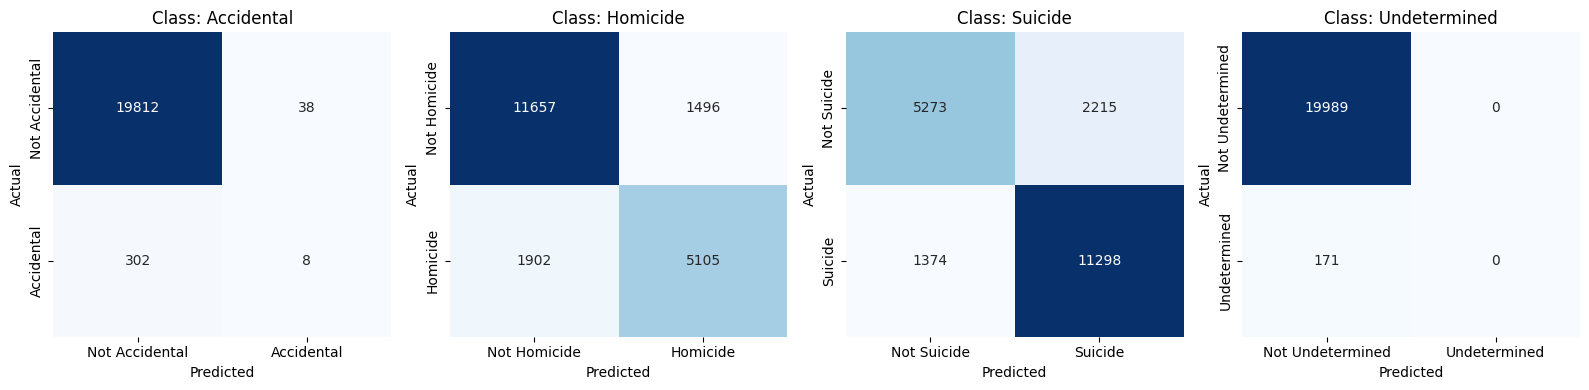

=== Tuned KNN Results ===
Accuracy: 0.8140
F1 (Macro): 0.4145

Classification Report:
              precision    recall  f1-score   support

  Accidental       0.17      0.03      0.04       310
    Homicide       0.77      0.73      0.75      7007
     Suicide       0.84      0.89      0.86     12672
Undetermined       0.00      0.00      0.00       171

    accuracy                           0.81     20160
   macro avg       0.45      0.41      0.41     20160
weighted avg       0.80      0.81      0.80     20160



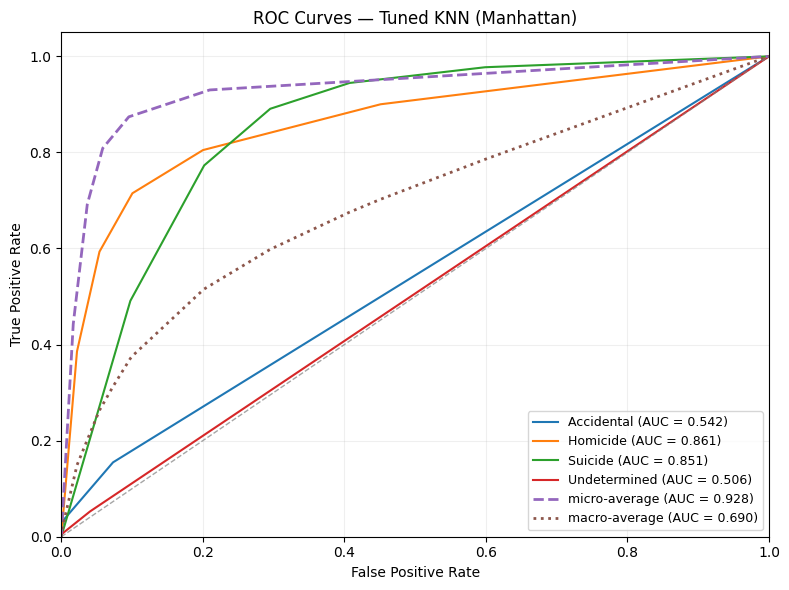

In [12]:
# ------------------------------------------------------------------
# 0. Make sure we have a label encoder with the ORIGINAL string labels
# ------------------------------------------------------------------
# y should be your original target with strings (e.g. "Accidental", "Homicide", ...)
label_encoder = LabelEncoder()
label_encoder.fit(y)   # fit on original labels

# ------------------------------------------------------------------
# 1. CONFUSION MATRICES (tuned KNN)
# ------------------------------------------------------------------

# Train tuned KNN (if not already trained)
knn_tuned.fit(x_train, y_train)

# Predictions (these are ints 0,1,2,3,...)
y_pred = knn_tuned.predict(x_test)

# Integer labels known by the model
class_labels = knn_tuned.classes_              # e.g. array([0,1,2,3])

# Map those ints back to the original label names
class_names = label_encoder.inverse_transform(class_labels)  # e.g. ['Accidental', 'Homicide', ...]

# One-vs-rest confusion matrices (still works with ints)
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=class_labels)

fig, axes = plt.subplots(1, len(class_labels), figsize=(4 * len(class_labels), 4))

if len(class_labels) == 1:
    axes = [axes]

for ax, cm, label_name in zip(axes, mcm, class_names):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {label_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels([f'Not {label_name}', label_name])
    ax.set_yticklabels([f'Not {label_name}', label_name])

plt.tight_layout()
plt.show()

# --- Metrics ---
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
print("=== Tuned KNN Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1_macro:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_labels,        # ints
        target_names=class_names,   # strings for display
        zero_division=0
    )
)

# ------------------------------------------------------------------
# 2. ROC CURVES (4 classes + micro + macro)
# ------------------------------------------------------------------

# Probabilities for each class (shape: [n_samples, n_classes])
y_score = knn_tuned.predict_proba(x_test)

# Binarize y_test to one-vs-rest format using integer class_labels
y_test_bin = label_binarize(y_test, classes=class_labels)
n_classes = len(class_labels)

fpr, tpr, roc_auc = {}, {}, {}

# Per-class ROC
for i, label_name in enumerate(class_names):
    fpr[label_name], tpr[label_name], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[label_name] = auc(fpr[label_name], tpr[label_name])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[label_name] for label_name in class_names]))
mean_tpr = np.zeros_like(all_fpr)

for label_name in class_names:
    mean_tpr += np.interp(all_fpr, fpr[label_name], tpr[label_name])

mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# --- Plot ROC curves ---
plt.figure(figsize=(8, 6))

# Per-class curves
for label_name in class_names:
    plt.plot(
        fpr[label_name], tpr[label_name], lw=1.5,
        label=f"{label_name} (AUC = {roc_auc[label_name]:.3f})"
    )

# Micro & macro
plt.plot(
    fpr["micro"], tpr["micro"],
    linestyle="--", lw=2,
    label=f"micro-average (AUC = {roc_auc['micro']:.3f})"
)
plt.plot(
    fpr["macro"], tpr["macro"],
    linestyle=":", lw=2,
    label=f"macro-average (AUC = {roc_auc['macro']:.3f})"
)

# Chance line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, alpha=0.7)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Tuned KNN (Manhattan)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()

# Decision Tree

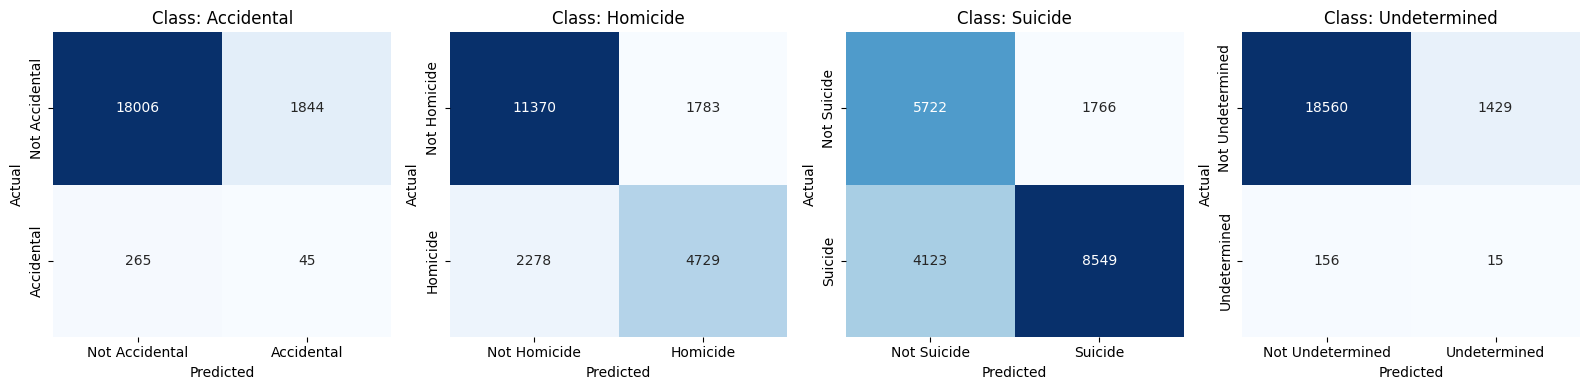

=== Decision Tree Results ===
Accuracy: 0.6616
F1 (Macro): 0.3757
Precision (Macro): 0.3973
Recall (Macro): 0.3956

Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.15      0.04       310
           1       0.73      0.67      0.70      7007
           2       0.83      0.67      0.74     12672
           3       0.01      0.09      0.02       171

    accuracy                           0.66     20160
   macro avg       0.40      0.40      0.38     20160
weighted avg       0.77      0.66      0.71     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.6616
Precision: 0.6616
Recall: 0.6616


In [13]:


# --- Decision Tree Model ---
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",     # or "gini"
        max_depth=None,          # you can limit depth to prevent overfitting
        class_weight="balanced", # handles imbalanced classes like 'Accidental' & 'Undetermined'
        random_state=42
    ))
])

# --- Train the model ---
dt_model.fit(x_train, y_train)

# --- Make predictions ---
y_pred = dt_model.predict(x_test)


# --- Get confusion matrix for each class ---
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(dt_model.classes_), figsize=(16, 4))

# Get the original class labels from the label encoder
original_labels = label_encoder.classes_

for i, (ax, label_index) in enumerate(zip(axes, dt_model.classes_)):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {original_labels[label_index]}') # Use original label for title
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.xaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks
    ax.yaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks


plt.tight_layout()
plt.show()

# --- Evaluate ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("=== Decision Tree Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comment:
# I chose max_depth = None, no limit on depth
# If some classes have much more data than others, the model might “cheat” and just focus on predicting the majority class correctly to boost accuracy.
# We use class_weight = "balanced" beacause we have imbalanced data (Accidental and Undetermined have very little samples)
# class_weight = "balanced" -> Automatically gives rare classes more importance, Helps the model not ignore small classes like Accidental and Undetermined
# However, this does not seem to help much as the scores for accidental and undetermined are still quite low

# To improve:
# we could tweak max_depth, bagging boosting, RF, Decision Stumps
# Can find information gain of each feature to see which features are best at predicting/splitting. Maybe can remove those with low info gain?


# Random Forest

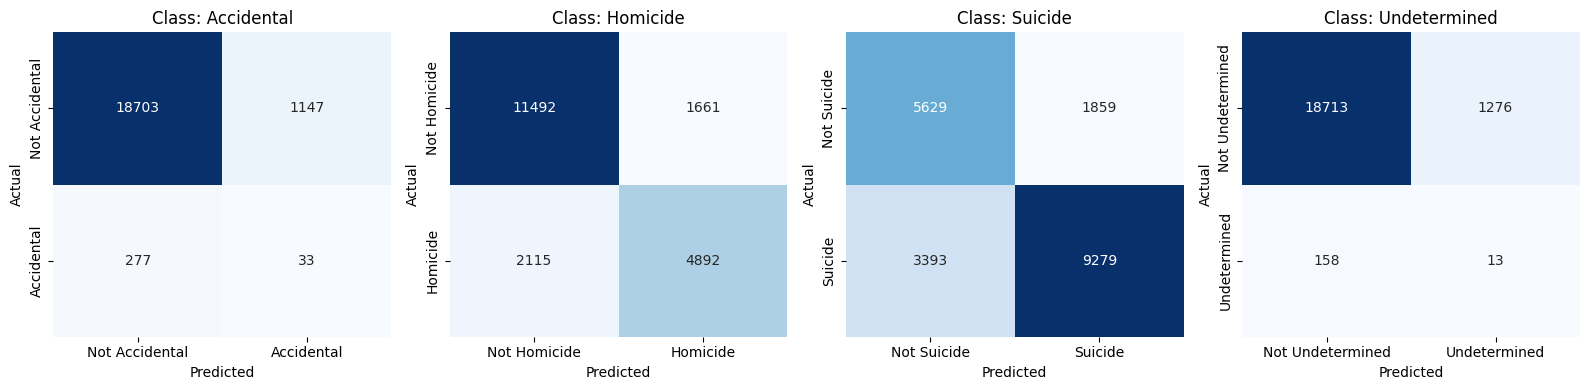

=== Random Forest Results ===
Accuracy: 0.7052
F1 (Macro): 0.3908
Precision (Macro): 0.4044
Recall (Macro): 0.4032

Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.11      0.04       310
           1       0.75      0.70      0.72      7007
           2       0.83      0.73      0.78     12672
           3       0.01      0.08      0.02       171

    accuracy                           0.71     20160
   macro avg       0.40      0.40      0.39     20160
weighted avg       0.78      0.71      0.74     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.7052
Precision: 0.7052
Recall: 0.7052


In [14]:
from sklearn.ensemble import RandomForestClassifier
# --- Random Forest Model ---
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,        # number of trees
        max_depth=None,          # allow trees to grow fully
        class_weight="balanced", # handle class imbalance
        random_state=42,
        n_jobs=-1                # use all CPU cores
    ))
])

# --- Train the model ---
rf_model.fit(x_train, y_train)

# --- Make predictions ---
y_pred = rf_model.predict(x_test)


### Confusion matrix ###

# --- Get confusion matrix for each class ---
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

# --- Plot one confusion matrix per class ---
fig, axes = plt.subplots(1, len(rf_model.classes_), figsize=(16, 4))

# Get the original class labels from the label encoder
original_labels = label_encoder.classes_

for i, (ax, label_index) in enumerate(zip(axes, rf_model.classes_)):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {original_labels[label_index]}') # Use original label for title
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.xaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks
    ax.yaxis.set_ticklabels(['Not ' + original_labels[label_index], original_labels[label_index]]) # Use original labels for ticks


plt.tight_layout()
plt.show()

# --- Evaluate ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("=== Random Forest Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

f1_micro = f1_score(y_test, y_pred, average="micro")
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

# Comments:
# Not sure if this is a baseline model, it could be an improvement to the baseline DT model
# Takes quite long to run also

# To improve:
# Can tune the no. of trees in the random forest and max_depth, can combine with bagging? Bagging is alr built in

### Feature importance

                                      Feature  Importance
0                                    num__Age    0.616414
14                            cat__Race_White    0.070329
11                            cat__Race_Black    0.055787
1                               num__Hispanic    0.034529
23              cat__Place of incident_Street    0.029239
16                cat__Place of incident_Home    0.024866
19   cat__Place of incident_Other unspecified    0.021931
5        cat__Education_Less than High School    0.015804
4                  cat__Education_High School    0.014357
6                 cat__Education_Some college    0.013781
3                    cat__Education_Bachelors    0.012709
8                             cat__Sex_Female    0.012351
18     cat__Place of incident_Other specified    0.011990
9                               cat__Sex_Male    0.011724
2                     num__Police involvement    0.010532
25         cat__Place of incident_Unspecified    0.006821
24  cat__Place

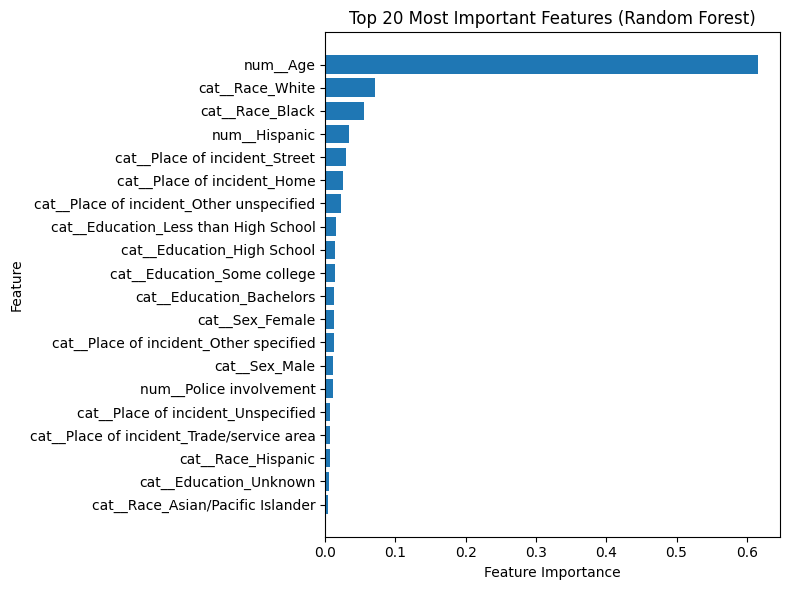

In [ ]:
# ---- Extract feature importances from the trained model ----
rf = rf_model.named_steps["classifier"]
importances = rf.feature_importances_

# ---- Get feature names from the preprocessor ----
# Works if your preprocessor uses ColumnTransformer
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# ---- Create a DataFrame and sort ----
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# ---- Display top 20 features ----
print(feat_imp.head(20))

# ---- Plot ----
plt.figure(figsize=(8, 6))
plt.barh(feat_imp["Feature"].head(20)[::-1],
         feat_imp["Importance"].head(20)[::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features (Random Forest)")
plt.tight_layout()
plt.show()

     original_feature  importance
0                 Age    0.616414
5                Race    0.139682
3   Place of incident    0.112874
1           Education    0.061894
2            Hispanic    0.034529
6                 Sex    0.024075
4  Police involvement    0.010532


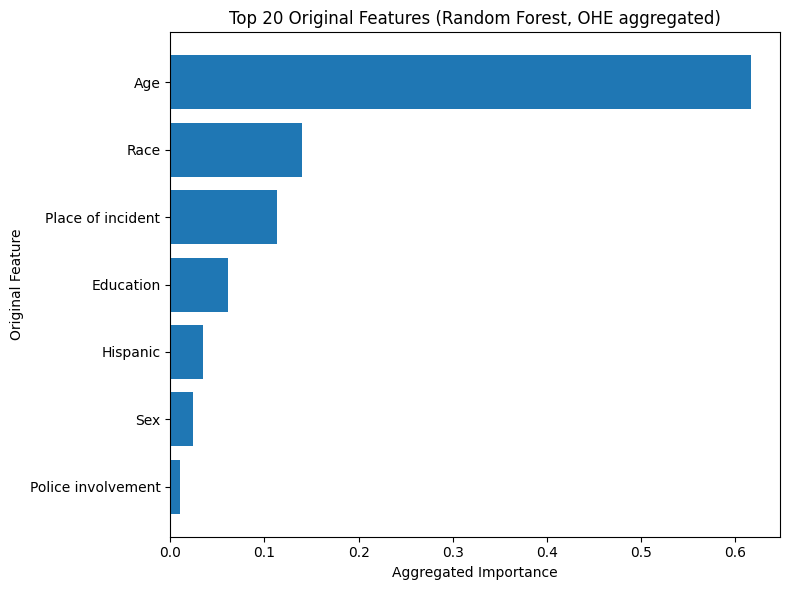

In [ ]:
pipe = rf_model

rf = pipe.named_steps["classifier"]
ct = pipe.named_steps["preprocessor"]

# 1) feature importances for the expanded (OHE) matrix
importances = rf.feature_importances_

# 2) names of the expanded columns
expanded_names = ct.get_feature_names_out()

# 3) map expanded names -> original feature names
#    - assumes ColumnTransformer named steps like "num" and "cat"
#    - for numeric: "num__Age"          -> "Age"
#    - for OHE:    "cat__Race_Black"    -> "Race"
def base_name(col):
    # strip ColumnTransformer prefix
    if "__" in col:
        prefix, rest = col.split("__", 1)
    else:
        rest = col
    # for OHE columns "Feature_Category" keep only the feature part
    if "_" in rest:
        return rest.split("_", 1)[0]
    return rest

original_names = [base_name(c) for c in expanded_names]

# 4) aggregate (sum) importances per original feature
agg = (
    pd.DataFrame({"original_feature": original_names,
                  "importance": importances})
    .groupby("original_feature", as_index=False)
    .sum()
    .sort_values("importance", ascending=False)
)

# 5) show and plot
print(agg.head(20))

topk = 20
plt.figure(figsize=(8, 6))
plt.barh(agg["original_feature"].head(topk)[::-1],
         agg["importance"].head(topk)[::-1])
plt.xlabel("Aggregated Importance")
plt.ylabel("Original Feature")
plt.title("Top {} Original Features (Random Forest, OHE aggregated)".format(topk))
plt.tight_layout()
plt.show()

# In this link: https://www.kaggle.com/code/sumiannn/d-trees-binary, they removed the reasons "Accidental" and "Undetermined" completely for the dataset and trained a decision tree.
# The most important feature became race. Maybe we can explore that.

#Improving on the Random Forest
### tuning the no. of trees and max_depth

In [15]:
# ----- Pipeline (same as yours, just parameterized) -----
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        bootstrap=True
    ))
])

# ----- Tuning only n_estimators and max_depth -----
param_grid = {
    "classifier__n_estimators": [100, 200, 400, 800],
    "classifier__max_depth": [None, 10, 20, 30, 40]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold for speed; use 5 if time permits
scoring = {
    "f1_macro": "f1_macro",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy"
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",   # pick the model by macro-F1
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# ----- Run search -----
grid.fit(x_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_

# ----- Test-set evaluation -----
y_pred = best_rf.predict(x_test)

acc  = accuracy_score(y_test, y_pred)
f1M  = f1_score(y_test, y_pred, average="macro", zero_division=0)
f1m  = f1_score(y_test, y_pred, average="micro", zero_division=0)
precM = precision_score(y_test, y_pred, average="macro", zero_division=0)
recM  = recall_score(y_test, y_pred, average="macro", zero_division=0)
balacc = balanced_accuracy_score(y_test, y_pred)

print("\n=== Tuned Random Forest Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Acc: {balacc:.4f}")
print(f"F1 (Macro): {f1M:.4f}")
print(f"F1 (Micro): {f1m:.4f}")
print(f"Precision (Macro): {precM:.4f}")
print(f"Recall (Macro): {recM:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# This will take very long to run, i gave up at 19 mins
# After this i still need to plot the ROC-AUC curve

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'classifier__max_depth': 10, 'classifier__n_estimators': 800}
Best CV macro-F1: 0.4199

=== Tuned Random Forest Results ===
Accuracy: 0.7160
Balanced Acc: 0.4623
F1 (Macro): 0.4158
F1 (Micro): 0.7160
Precision (Macro): 0.4313
Recall (Macro): 0.4623

Classification Report:
              precision    recall  f1-score   support

           0       0.05      0.22      0.08       310
           1       0.78      0.75      0.77      7007
           2       0.88      0.71      0.79     12672
           3       0.02      0.16      0.03       171

    accuracy                           0.72     20160
   macro avg       0.43      0.46      0.42     20160
weighted avg       0.83      0.72      0.76     20160



# XGBoost Classifier

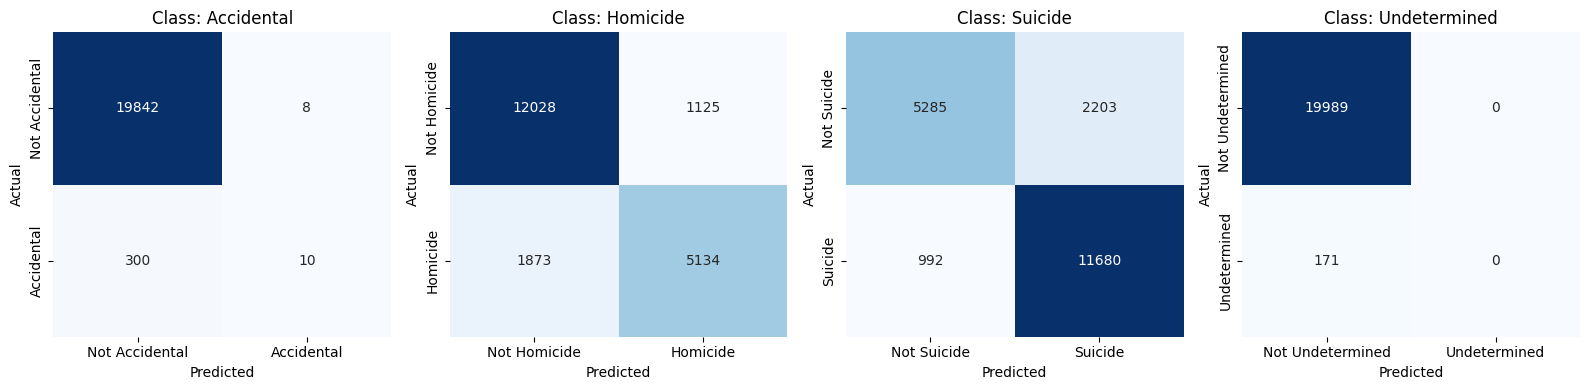

=== XGBoost Results ===
Accuracy: 0.8345
F1 (Macro): 0.4287
Precision (Macro): 0.5543
Recall (Macro): 0.4217

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.03      0.06       310
           1       0.82      0.73      0.77      7007
           2       0.84      0.92      0.88     12672
           3       0.00      0.00      0.00       171

    accuracy                           0.83     20160
   macro avg       0.55      0.42      0.43     20160
weighted avg       0.82      0.83      0.82     20160


=== Micro-Averaged Metrics ===
F1 Score: 0.8345
Precision: 0.8345
Recall: 0.8345


In [16]:
# --- XGBoost Model ---
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",   # multiclass probability output
        eval_metric="mlogloss",       # avoids warning; metric for training
        n_estimators=300,             # number of trees (can tune)
        learning_rate=0.1,            # step size shrinkage
        max_depth=6,                  # tree depth (controls complexity)
        subsample=0.8,                # row subsampling
        colsample_bytree=0.8,         # feature subsampling
        random_state=42,
        tree_method="hist",           # fast on CPU
        n_jobs=-1                     # use all cores
    ))
])

# --- Train the model ---
xgb_model.fit(x_train, y_train)

# --- Predictions ---
y_pred = xgb_model.predict(x_test)

# ------------------------------------------------------------------
# Confusion matrices (one-vs-rest per class)
# ------------------------------------------------------------------
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=xgb_model.classes_)

fig, axes = plt.subplots(1, len(xgb_model.classes_), figsize=(4 * len(xgb_model.classes_), 4))

# original_labels: from your existing LabelEncoder (string names)
original_labels = label_encoder.classes_

for i, (ax, label_index) in enumerate(zip(axes, xgb_model.classes_)):
    cm = mcm[i]
    label_name = original_labels[label_index]  # e.g. "Accidental"
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Class: {label_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels([f'Not {label_name}', label_name])
    ax.set_yticklabels([f'Not {label_name}', label_name])

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("=== XGBoost Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (Macro): {f1_macro:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

f1_micro = f1_score(y_test, y_pred, average="micro", zero_division=0)
precision_micro = precision_score(y_test, y_pred, average="micro", zero_division=0)
recall_micro = recall_score(y_test, y_pred, average="micro", zero_division=0)

print("\n=== Micro-Averaged Metrics ===")
print(f"F1 Score: {f1_micro:.4f}")
print(f"Precision: {precision_micro:.4f}")
print(f"Recall: {recall_micro:.4f}")

## Tuning the XGBoost Classifier

In [19]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# ------------------------------------------------------------
# 1. Base XGBoost pipeline
# ------------------------------------------------------------
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",   # fast on CPU
        n_jobs=-1,
        random_state=42
    )),
])

# ------------------------------------------------------------
# 2. Hyperparameter search space
#    (tuning n_estimators, max_depth, learning_rate)
# ------------------------------------------------------------
param_dist = {
    "classifier__n_estimators": [100, 200, 400, 600],
    "classifier__max_depth": [3, 4, 5, 6, 7, 8, 9],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "f1_macro": "f1_macro",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=20,                 # number of random combos to try
    scoring=scoring,
    refit="f1_macro",          # pick best by macro-F1
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# ------------------------------------------------------------
# 3. Run search
# ------------------------------------------------------------
xgb_search.fit(x_train, y_train)

print("Best params:", xgb_search.best_params_)
print(f"Best CV macro-F1: {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_

# ------------------------------------------------------------
# 4. Evaluate best XGBoost on test set
# ------------------------------------------------------------
y_pred = best_xgb.predict(x_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Acc": balanced_accuracy_score(y_test, y_pred),
    "F1 (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "F1 (Micro)": f1_score(y_test, y_pred, average="micro", zero_division=0),
    "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
}

print("\n=== Tuned XGBoost Test Metrics ===")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'classifier__n_estimators': 200, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.2}
Best CV macro-F1: 0.4279

=== Tuned XGBoost Test Metrics ===
Accuracy: 0.8332
Balanced Acc: 0.4204
F1 (Macro): 0.4265
F1 (Micro): 0.8332
Precision (Macro): 0.5395
Recall (Macro): 0.4204

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.03      0.05       310
           1       0.82      0.73      0.77      7007
           2       0.84      0.92      0.88     12672
           3       0.00      0.00      0.00       171

    accuracy                           0.83     20160
   macro avg       0.54      0.42      0.43     20160
weighted avg       0.82      0.83      0.82     20160



# Comparing the models

#General Comments:




I dropped the date features, not sure if i should. Can do Weekend vs Weekday


Better to use micro metrics than macro metrics beacause of our imbalanced dataset. In general, the macro metrics is quite low for all models this is because of the low number of samples for accidental and undetermined classes

Accuracy and Micro metrics KNN is by far the best. But accuracy does not tell the full story

Can use other evaluation methods like AUC-ROC(plot 6 AUC-ROC curves micro macro and one for each class) , PR-AUC  normalised confusion matrix to evaluate

Can check if model is underfitting or overfitting by comparing training performance vs test performance

To improve the models in general, we have to increase the samples of accidental and undetermined. We also have to tune certain parameters. We can also do feature engineering or feature selection. Find the top predictors?

To do:

do feature importance and see what features to drop

check feature impact on model for features that are imbalanced

Find out how does the imbalanced data (in this case the imbalanced classes in reasons) affect the model


